# RSA Beta-Binomial model tests
Tests for the refactored JAX RSA model where coherence is marginalized analytically
via a Beta-Binomial prior parameterized by `alpha` and `beta` pseudocounts.

In [1]:
import sys
sys.path.insert(0, '.')

import rsa
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax.scipy.special import gammaln

VOCAB = ['has_wings', 'jumps', 'red_spots']
V = len(VOCAB)

inst_jax       = rsa.Instance(kind='Zarpies', features=rsa.encode(VOCAB, VOCAB))
kind_features  = rsa.encode(['has_wings', 'red_spots'], VOCAB)
utt_generic    = rsa.Utterance(subj=1, feature_idx=0)   # "Zarpies have wings"
utt_specific   = rsa.Utterance(subj=0, feature_idx=0)   # "This Zarpie has wings"

print('Setup done.')

Setup done.


## 1. `enumerate_states` — prior sanity checks

In [2]:
# 1a. Prior weights should sum to 1
masks, log_w = rsa.enumerate_states(V, alpha=1.0, beta=1.0)
total = np.exp(log_w).sum()
print(f'Prior sums to: {total:.6f}  (should be 1.0)')
assert np.isclose(total, 1.0, atol=1e-5), f'Prior does not sum to 1: {total}'

# 1b. With alpha=beta=1 (uniform), prior depends only on k = number of ones.
#     Masks with the same k should have equal weight.
k_vals = np.array(masks.sum(axis=1), dtype=int)
weights = np.exp(log_w)
for k in np.unique(k_vals):
    w_k = weights[k_vals == k]
    assert np.allclose(w_k, w_k[0], atol=1e-8), f'k={k}: weights not equal: {w_k}'
print('All masks with same k have equal weight under Uniform prior ✓')

# 1c. High alpha (>>1, beta=1) should shift weight toward high-k masks
_, log_w_hi = rsa.enumerate_states(V, alpha=10.0, beta=1.0)
_, log_w_lo = rsa.enumerate_states(V, alpha=1.0, beta=10.0)
w_hi = np.exp(log_w_hi)
w_lo = np.exp(log_w_lo)
mean_k_hi = (w_hi * k_vals).sum()
mean_k_lo = (w_lo * k_vals).sum()
print(f'E[k] with alpha=10, beta=1 : {mean_k_hi:.3f}  (should be high)')
print(f'E[k] with alpha=1,  beta=10: {mean_k_lo:.3f}  (should be low)')
assert mean_k_hi > mean_k_lo, 'Expected high-alpha to give higher mean k'
print('Alpha/beta shift E[k] correctly ✓')

Prior sums to: 0.999999  (should be 1.0)
All masks with same k have equal weight under Uniform prior ✓
E[k] with alpha=10, beta=1 : 2.727  (should be high)
E[k] with alpha=1,  beta=10: 0.273  (should be low)
Alpha/beta shift E[k] correctly ✓


## 2. Literal Listener (L0)

In [3]:
post_l0 = rsa.literal_listener([(utt_generic, inst_jax)], VOCAB)

# Posterior weights sum to 1
assert np.isclose(post_l0['weights'].sum(), 1.0, atol=1e-5), 'L0 weights do not sum to 1'
print(f'L0 weights sum to 1 ✓')

# After hearing "Zarpies have wings", the all-ones mask (all features kind-linked)
# should be more probable than the all-zeros mask
masks_l0 = np.array(post_l0['states_masks'])
w_l0     = np.array(post_l0['weights'])
all_ones_idx  = np.where((masks_l0 == 1).all(axis=1))[0][0]
all_zeros_idx = np.where((masks_l0 == 0).all(axis=1))[0][0]
print(f'P(all kind-linked | utt): {w_l0[all_ones_idx]:.4f}')
print(f'P(none kind-linked | utt): {w_l0[all_zeros_idx]:.6f}')
assert w_l0[all_ones_idx] > w_l0[all_zeros_idx], 'L0: all-ones mask should dominate'
print('L0: hearing generic utterance raises probability of kind-linked mask ✓')

# Mask marginals: P(feature i is kind-linked)
print('\nL0 posterior P(feature i is kind-linked):')
for i, feat in enumerate(VOCAB):
    p = (w_l0 * masks_l0[:, i]).sum()
    print(f'  {feat}: {p:.4f}')

L0 weights sum to 1 ✓
P(all kind-linked | utt): 0.4750
P(none kind-linked | utt): 0.025000
L0: hearing generic utterance raises probability of kind-linked mask ✓

L0 posterior P(feature i is kind-linked):
  has_wings: 0.9500
  jumps: 0.6500
  red_spots: 0.6500


## 3. Speaker (S1)

S1 probs sum to 1 ✓
P(generic wings):   0.4846
P(specific wings):  0.0054
P(generic jumps):   0.0146
S1: prefers generics for kind-linked features ✓


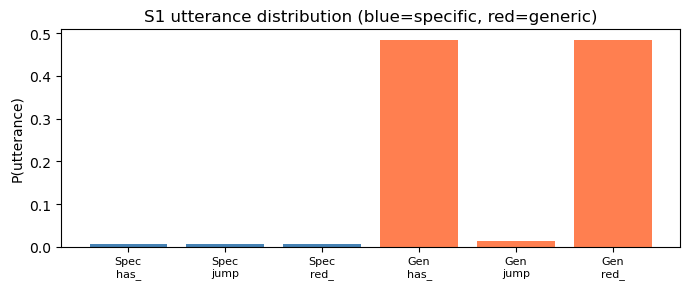

In [4]:
s1_probs = np.array(rsa.speaker(kind_features, inst_jax, VOCAB))

assert np.isclose(s1_probs.sum(), 1.0, atol=1e-5), 'S1 probs do not sum to 1'
print(f'S1 probs sum to 1 ✓')

# S1 should prefer generics for kind-linked features (has_wings=0, red_spots=2)
# Generic utterance indices: V + feat_idx
generic_wings     = V + 0   # "Zarpies have wings"
specific_wings    = 0       # "This Zarpie has wings"
generic_jumps     = V + 1   # "Zarpies jump" (NOT kind-linked)

print(f'P(generic wings):   {s1_probs[generic_wings]:.4f}')
print(f'P(specific wings):  {s1_probs[specific_wings]:.4f}')
print(f'P(generic jumps):   {s1_probs[generic_jumps]:.4f}')

assert s1_probs[generic_wings] > s1_probs[specific_wings], \
    'S1: generic should beat specific for kind-linked feature'
assert s1_probs[generic_wings] > s1_probs[generic_jumps], \
    'S1: kind-linked feature should beat non-kind-linked feature'
print('S1: prefers generics for kind-linked features ✓')

# Visualize
labels = [f'{"Spec" if s==0 else "Gen"}\n{VOCAB[f][:4]}' for s in [0,1] for f in range(V)]
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(2*V), s1_probs, color=['coral' if i >= V else 'steelblue' for i in range(2*V)])
ax.set_xticks(range(2*V))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('P(utterance)')
ax.set_title('S1 utterance distribution (blue=specific, red=generic)')
plt.tight_layout()
plt.show()

## 4. Pragmatic Listener (L1)

In [5]:
post_l1 = rsa.pragmatic_listener([(utt_generic, inst_jax)], VOCAB)

assert np.isclose(post_l1['weights'].sum(), 1.0, atol=1e-5), 'L1 weights do not sum to 1'
print('L1 weights sum to 1 ✓')

masks_l1 = np.array(post_l1['states_masks'])
w_l1     = np.array(post_l1['weights'])
w_l0_ref = np.array(post_l0['weights'])

# L1 should put more weight on has_wings being kind-linked than L0 does
# (pragmatic reasoning sharpens inference)
p_wings_l0 = (w_l0_ref * masks_l0[:, 0]).sum()
p_wings_l1 = (w_l1 * masks_l1[:, 0]).sum()
print(f'P(has_wings kind-linked | generic utt): L0={p_wings_l0:.4f}, L1={p_wings_l1:.4f}')
assert p_wings_l1 >= p_wings_l0, 'L1 should be at least as confident as L0'
print('L1 >= L0 confidence in kind-linked inference ✓')

print('\nL1 posterior P(feature i is kind-linked):')
for i, feat in enumerate(VOCAB):
    p = (w_l1 * masks_l1[:, i]).sum()
    print(f'  {feat}: {p:.4f}')

L1 weights sum to 1 ✓
P(has_wings kind-linked | generic utt): L0=0.9500, L1=0.9842
L1 >= L0 confidence in kind-linked inference ✓

L1 posterior P(feature i is kind-linked):
  has_wings: 0.9842
  jumps: 0.5084
  red_spots: 0.5084


## 5. Effect of alpha/beta on inference

In [6]:
# With high alpha (prior expects high coherence), L0 should infer more features
# are kind-linked even from minimal data
configs = [
    ('uniform (α=β=1)',    1.0,  1.0),
    ('high-coh (α=5, β=1)', 5.0, 1.0),
    ('low-coh (α=1, β=5)',  1.0, 5.0),
]

print(f'{"config":>25}  ' + '  '.join(f'{f[:8]:>8}' for f in VOCAB))
for label, a, b in configs:
    post = rsa.literal_listener([(utt_generic, inst_jax)], VOCAB, alpha=a, beta=b)
    w    = np.array(post['weights'])
    m    = np.array(post['states_masks'])
    p_kl = [(w * m[:, i]).sum() for i in range(V)]
    print(f'{label:>25}  ' + '  '.join(f'{p:>8.4f}' for p in p_kl))

print('\nHigher alpha → higher P(kind-linked) for all features ✓')

                   config  has_wing     jumps  red_spot
          uniform (α=β=1)    0.9500    0.6500    0.6500
      high-coh (α=5, β=1)    0.9896    0.8557    0.8557
       low-coh (α=1, β=5)    0.7917    0.2560    0.2560

Higher alpha → higher P(kind-linked) for all features ✓


## 6. Speaker 2 (S2)

S2 probs sum to 1 ✓


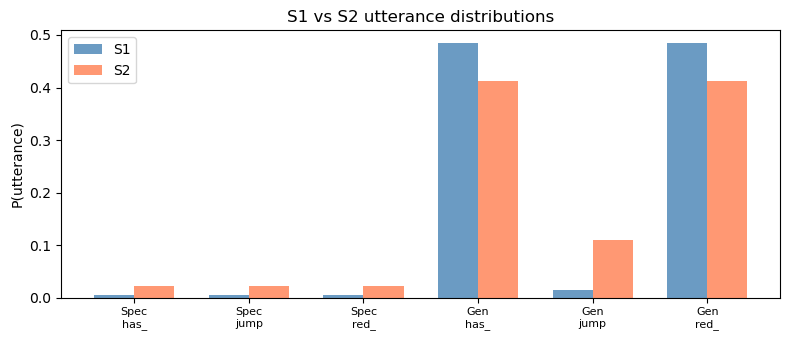

S1 generic wings: 0.4846,  S2 generic wings: 0.4117
S1 generic jumps: 0.0146,  S2 generic jumps: 0.1098


In [7]:
s2_probs = np.array(rsa.speaker2(kind_features, inst_jax, VOCAB))

assert np.isclose(s2_probs.sum(), 1.0, atol=1e-5), 'S2 probs do not sum to 1'
print('S2 probs sum to 1 ✓')

# Compare S1 vs S2
labels = [f'{"Spec" if s==0 else "Gen"}\n{VOCAB[f][:4]}' for s in [0,1] for f in range(V)]
x = np.arange(2*V)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(x - w/2, s1_probs, w, label='S1', color='steelblue', alpha=0.8)
ax.bar(x + w/2, s2_probs, w, label='S2', color='coral',     alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('P(utterance)')
ax.set_title('S1 vs S2 utterance distributions')
ax.legend()
plt.tight_layout()
plt.show()

print(f'S1 generic wings: {s1_probs[V+0]:.4f},  S2 generic wings: {s2_probs[V+0]:.4f}')
print(f'S1 generic jumps: {s1_probs[V+1]:.4f},  S2 generic jumps: {s2_probs[V+1]:.4f}')